## Multi-Country Regional Malaria DQA Pipeline
This notebook generates a simulated multi-country health facility dataset, runs automated Data Quality Assurance (DQA) validation checks based on WHO standards, and visualizes the systemic reporting anomalies.

In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime

# Seed for reproducibility
np.random.seed(42)
random.seed(42)

# Generate 50 simulated facilities across East Africa
facilities = []
countries = ['Kenya', 'Uganda', 'Tanzania']
sub_counties = {'Kenya': ['Kibera', 'Mathare', 'Langata'], 
                'Uganda': ['Gulu', 'Lira', 'Kitgum'], 
                'Tanzania': ['Arusha', 'Moshi', 'Karatu']}
focal_persons = {'Kenya': 'J. Kamau', 'Uganda': 'S. Okello', 'Tanzania': 'M. Ndlovu'}

for i in range(1, 51):
    country = random.choice(countries)
    sub_county = random.choice(sub_counties[country])
    facilities.append({
        'facility_id': f"{country[:2].upper()}-{sub_county[:3].upper()}-10{i}",
        'facility_name': f"{sub_county} Health Centre {i}",
        'country': country,
        'region_district': sub_county,
        'facility_tier': random.choice(['Dispensary', 'Health Centre']),
        'reporting_period': '2026-08-01',
        'focal_person': focal_persons[country]
    })

df = pd.DataFrame(facilities)

# Generate Baseline Clean Data
df['opd_attendance'] = np.random.randint(500, 2000, size=50)
df['suspected_malaria'] = (df['opd_attendance'] * np.random.uniform(0.2, 0.4)).astype(int)
df['tests_conducted'] = (df['suspected_malaria'] * np.random.uniform(0.9, 1.0)).astype(int)
df['positive_cases'] = (df['tests_conducted'] * np.random.uniform(0.1, 0.4)).astype(int)
df['act_dispensed'] = df['positive_cases']
df['severe_referred'] = (df['positive_cases'] * np.random.uniform(0.01, 0.05)).astype(int)
df['submitted_on_time'] = np.random.choice([True, False], size=50, p=[0.85, 0.15])

# INJECT DELIBERATE DQA ERRORS FOR THE PIPELINE TO CATCH

# Gate 1: Completeness (Missing tests_conducted in 3 facilities)
df.loc[3:5, 'tests_conducted'] = np.nan

# Gate 2: Logic Contradiction (Positives exceed Tests in 4 facilities)
df.loc[10:13, 'positive_cases'] = df.loc[10:13, 'tests_conducted'] + np.random.randint(20, 50, size=4)

# Gate 3: Protocol Variance (ACT Dispensed drastically exceeds Positives - Irrational Prescribing)
df.loc[20:25, 'act_dispensed'] = (df.loc[20:25, 'positive_cases'] * 2.5).astype(int)

# Gate 4: Epidemiological Outlier (Suspiciously high positivity rate > 90%)
df.loc[35:36, 'positive_cases'] = (df.loc[35:36, 'tests_conducted'] * 0.95).astype(int)

# Save to CSV
df.to_csv('regional_malaria_data.csv', index=False)
print("Mock dataset 'regional_malaria_data.csv' with 50 facilities generated successfully.")

Mock dataset 'regional_malaria_data.csv' with 50 facilities generated successfully.


## 1. DQA Logic Validation & Interactive Visualizations
The following engine runs the data through 4 logic gates (Completeness, Logic Contradiction, Protocol Variance, Epidemiological Outlier) and renders interactive Plotly dashboards.

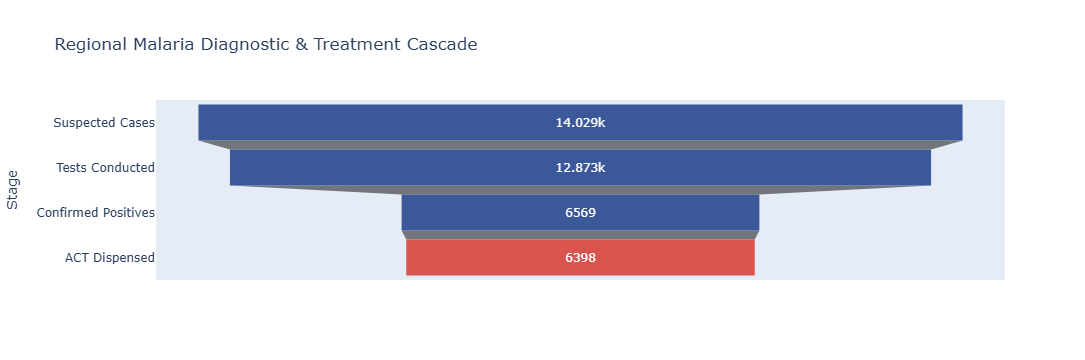

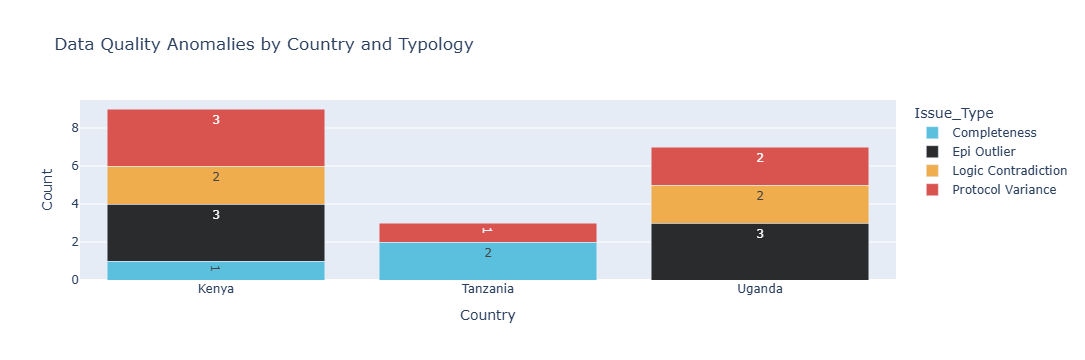

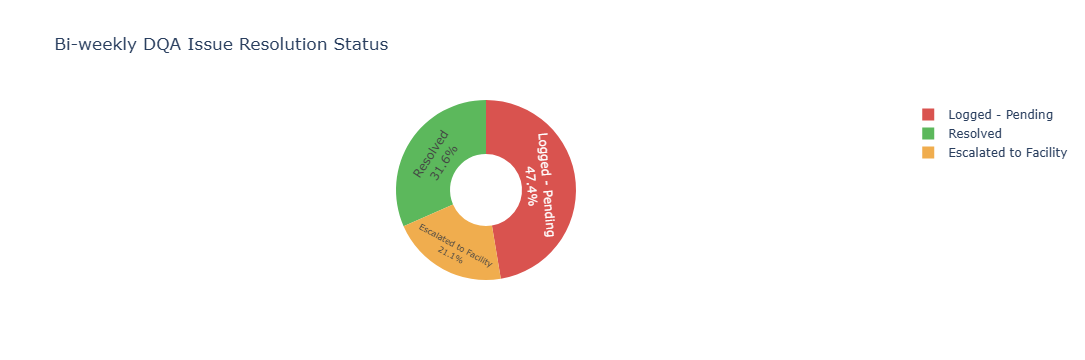

In [9]:
### 2. DQA Logic Validation

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import random

# 1. LOAD DATA & RUN DQA ENGINE (To generate the issue log for our visuals)
df = pd.read_csv('regional_malaria_data.csv')
issue_log = []

for index, row in df.iterrows():
    facility = row['facility_id']
    country = row['country']
    
    # Gate 1: Completeness
    if pd.isna(row['tests_conducted']):
        issue_log.append({'Country': country, 'Issue_Type': 'Completeness', 'Status': 'Logged - Pending'})
        continue
        
    # Gate 2: Logic Contradiction
    if row['positive_cases'] > row['tests_conducted']:
        issue_log.append({'Country': country, 'Issue_Type': 'Logic Contradiction', 'Status': 'Escalated to Facility'})
        
    # Gate 3: Protocol Variance
    if row['act_dispensed'] > (row['positive_cases'] * 1.05):
        issue_log.append({'Country': country, 'Issue_Type': 'Protocol Variance', 'Status': 'Resolved'})
        
    # Gate 4: Epidemiological Outlier (Positivity > 85%)
    if (row['positive_cases'] / row['tests_conducted']) > 0.85:
         issue_log.append({'Country': country, 'Issue_Type': 'Epi Outlier', 'Status': 'Logged - Pending'})

issues_df = pd.DataFrame(issue_log)

# ==========================================
# VISUAL 1: The Diagnostic Cascade Funnel
# Highlights clinical protocol variances (e.g., ACT dispensed > Positives)
# ==========================================

# Aggregate regional totals
cascade_data = dict(
    Stage=['Suspected Cases', 'Tests Conducted', 'Confirmed Positives', 'ACT Dispensed'],
    Count=[
        df['suspected_malaria'].sum(),
        df['tests_conducted'].sum(),
        df['positive_cases'].sum(),
        df['act_dispensed'].sum()
    ]
)

fig1 = px.funnel(
    cascade_data, x='Count', y='Stage',
    title='Regional Malaria Diagnostic & Treatment Cascade',
    labels={'Count': 'Total Patients'}
)
# Update colors to highlight the protocol variance at the bottom of the funnel
fig1.update_traces(marker=dict(color=['#3b5998', '#3b5998', '#3b5998', '#d9534f']))
fig1.show()

# ==========================================
# VISUAL 2: DQA Error Severity by Country
# Shows executives exactly which region needs intervention
# ==========================================

error_counts = issues_df.groupby(['Country', 'Issue_Type']).size().reset_index(name='Count')

fig2 = px.bar(
    error_counts, x='Country', y='Count', color='Issue_Type',
    title='Data Quality Anomalies by Country and Typology',
    text='Count', barmode='stack',
    color_discrete_map={
        'Protocol Variance': '#d9534f', # Red for severe clinical issues
        'Logic Contradiction': '#f0ad4e', # Orange 
        'Completeness': '#5bc0de',
        'Epi Outlier': '#292b2c'
    }
)
fig2.show()

# ==========================================
# VISUAL 3: DQA Audit Resolution Status
# Proves you track remediation, not just error spotting
# ==========================================

status_counts = issues_df['Status'].value_counts().reset_index()
status_counts.columns = ['Status', 'Count']

fig3 = px.pie(
    status_counts, values='Count', names='Status', hole=0.4,
    title='Bi-weekly DQA Issue Resolution Status',
    color='Status',
    color_discrete_map={
        'Resolved': '#5cb85c', 
        'Escalated to Facility': '#f0ad4e',
        'Logged - Pending': '#d9534f'
    }
)
fig3.update_traces(textposition='inside', textinfo='percent+label')
fig3.show()

## 2. Static Dashboard Export & Issue Logging
This section exports the generated DQA anomalies to an Excel Issue Log for country focal points, and saves high-resolution static charts for external reporting.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. LOAD DATA & GENERATE ISSUE LOG
df = pd.read_csv('regional_malaria_data.csv')
issue_log = []

for index, row in df.iterrows():
    facility = row['facility_id']
    country = row['country']
    
    if pd.isna(row['tests_conducted']):
        issue_log.append({'Country': country, 'Issue_Type': 'Completeness', 'Status': 'Logged - Pending'})
        continue
        
    if row['positive_cases'] > row['tests_conducted']:
        issue_log.append({'Country': country, 'Issue_Type': 'Logic Contradiction', 'Status': 'Escalated to Facility'})
        
    if row['act_dispensed'] > (row['positive_cases'] * 1.05):
        issue_log.append({'Country': country, 'Issue_Type': 'Protocol Variance', 'Status': 'Resolved'})
        
    if (row['positive_cases'] / row['tests_conducted']) > 0.85:
        issue_log.append({'Country': country, 'Issue_Type': 'Epi Outlier', 'Status': 'Logged - Pending'})

issues_df = pd.DataFrame(issue_log)

# Ensure Excel file is saved
excel_filename = "Biweekly_DQA_Issue_Log.xlsx"
issues_df.to_excel(excel_filename, index=False)

# ==========================================
# VISUAL 1: Regional Diagnostic Cascade
# ==========================================
stages = ['Suspected Cases', 'Tests Conducted', 'Confirmed Positives', 'ACT Dispensed']
counts = [
    df['suspected_malaria'].sum(),
    df['tests_conducted'].sum(),
    df['positive_cases'].sum(),
    df['act_dispensed'].sum()
]
colors = ['#2b5c8f', '#2b5c8f', '#2b5c8f', '#c9302c']

plt.figure(figsize=(9, 5))
bars = plt.barh(stages[::-1], counts[::-1], color=colors[::-1])
plt.title('Regional Malaria Diagnostic & Treatment Cascade', fontsize=14, pad=15, weight='bold')
plt.xlabel('Total Patients', fontsize=11)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 200, bar.get_y() + bar.get_height()/2, f'{int(width):,}', 
             va='center', ha='left', fontsize=10, weight='bold')

plt.xlim(0, max(counts) * 1.15)
plt.tight_layout()
plt.savefig('diagnostic_cascade_funnel.png', dpi=300)
plt.close()

# ==========================================
# VISUAL 2: Anomalies by Country (Stacked Bar)
# ==========================================
pivot_df = issues_df.pivot_table(index='Country', columns='Issue_Type', aggfunc='size', fill_value=0)
palette = ['#5bc0de', '#292b2c', '#f0ad4e', '#d9534f']

ax = pivot_df.plot(kind='bar', stacked=True, figsize=(8, 5), color=palette, edgecolor='none')
plt.title('Data Quality Anomalies by Country and Typology', fontsize=14, pad=15, weight='bold')
plt.ylabel('Count of Anomalies', fontsize=11)
plt.xlabel('Country', fontsize=11)
plt.xticks(rotation=0)
plt.legend(title='Issue Type', frameon=True)
plt.tight_layout()
plt.savefig('dqa_error_severity.png', dpi=300)
plt.close()

# ==========================================
# VISUAL 3: Issue Resolution Status (Donut)
# ==========================================
status_counts = issues_df['Status'].value_counts()
status_colors = {'Resolved': '#5cb85c', 'Escalated to Facility': '#f0ad4e', 'Logged - Pending': '#d9534f'}
plot_colors = [status_colors.get(s, '#999999') for s in status_counts.index]

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    status_counts, 
    labels=status_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=plot_colors,
    wedgeprops=dict(width=0.45, edgecolor='w')
)
for at in autotexts:
    at.set_color('white')
    at.set_weight('bold')

plt.title('Bi-weekly DQA Issue Resolution Status', fontsize=14, pad=15, weight='bold')
plt.tight_layout()
plt.savefig('dqa_resolution_status.png', dpi=300)
plt.close()

# Print status and open folder
print(f"Generated:")
print(f"- diagnostic_cascade_funnel.png")
print(f"- dqa_error_severity.png")
print(f"- dqa_resolution_status.png")
print(f"- {excel_filename}")
print(f"Current Directory: {os.getcwd()}")


Generated:
- diagnostic_cascade_funnel.png
- dqa_error_severity.png
- dqa_resolution_status.png
- Biweekly_DQA_Issue_Log.xlsx
Current Directory: C:\Users\ADMIN
